<a href="https://colab.research.google.com/github/MUTARAMBIRWAJo/RideConnect/blob/main/RideConnectModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
CSV_PATH = "/content/kigali_demand_dataset.csv"

# Verify the variable was actually changed:
print("CSV_PATH is now:", CSV_PATH)

# Verify the file exists at that path:
import os
print("File exists:", os.path.exists(CSV_PATH))
print("File size:", os.path.getsize(CSV_PATH) / (1024*1024), "MB")

CSV_PATH is now: /content/kigali_demand_dataset.csv
File exists: True
File size: 22.539997100830078 MB


In [11]:
import pandas as pd

df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

EXPECTED_ROWS  = 259_200
EXPECTED_ZONES = 15
EXPECTED_START = pd.Timestamp("2025-11-01 00:00:00")
EXPECTED_END   = pd.Timestamp("2026-04-29 23:45:00")

print(f"Rows:        {len(df):,}   (expected {EXPECTED_ROWS:,})")
print(f"Zones:       {df.zone_id.nunique()}   (expected {EXPECTED_ZONES})")
print(f"Date range:  {df.timestamp.min()}  →  {df.timestamp.max()}")

assert len(df) == EXPECTED_ROWS
assert df.zone_id.nunique() == EXPECTED_ZONES
assert df.timestamp.min() == EXPECTED_START
assert df.timestamp.max() == EXPECTED_END
assert df.isna().sum().sum() == 0

per_zone = df.groupby("zone_id").size()
assert (per_zone == 17_280).all()

print("\n✅ Dataset integrity verified — all 259,200 rows present.")

Rows:        259,200   (expected 259,200)
Zones:       15   (expected 15)
Date range:  2025-11-01 00:00:00  →  2026-04-29 23:45:00

✅ Dataset integrity verified — all 259,200 rows present.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# **LSTM Implementation**

## **Cell 2.1 — Cyclical time encoding**

In [13]:
# WHY: hour 23 and hour 0 are 1 hour apart, but as raw numbers they look 23 apart.
# sin/cos puts them on a circle — the model sees the proximity correctly.
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 7)

print("Cyclical encoding example (hour 23 vs hour 0 — should be neighbors on the circle):")
print(df[df.hour.isin([0, 12, 23])][["hour", "hour_sin", "hour_cos"]].drop_duplicates())

Cyclical encoding example (hour 23 vs hour 0 — should be neighbors on the circle):
      hour      hour_sin  hour_cos
0        0  0.000000e+00  1.000000
720     12  1.224647e-16 -1.000000
1380    23 -2.588190e-01  0.965926


## **Cell 2.2 — One-hot encode weather and zones**

In [14]:
weather_dummies = pd.get_dummies(df["weather"], prefix="wx").astype(int)
zone_dummies    = pd.get_dummies(df["zone_id"], prefix="zone").astype(int)
df = pd.concat([df, weather_dummies, zone_dummies], axis=1)

print(f"Weather dummies: {list(weather_dummies.columns)}")
print(f"Zone dummies (15): {list(zone_dummies.columns)}")
print(f"Dataframe shape: {df.shape}")

Weather dummies: ['wx_cloudy', 'wx_heavy_rain', 'wx_light_rain', 'wx_sunny']
Zone dummies (15): ['zone_Z01', 'zone_Z02', 'zone_Z03', 'zone_Z04', 'zone_Z05', 'zone_Z06', 'zone_Z07', 'zone_Z08', 'zone_Z09', 'zone_Z10', 'zone_Z11', 'zone_Z12', 'zone_Z13', 'zone_Z14', 'zone_Z15']
Dataframe shape: (259200, 40)


## **Cell 2.3 — Lag features (per zone)**

In [15]:
# WHY: explicit lags help the model use short-term memory without burning
# LSTM capacity on rediscovering "what was demand 15 min ago"
df = df.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)
for lag in [1, 4, 96]:                          # 15min, 1h, 24h
    df[f"lag_{lag}"] = df.groupby("zone_id")["request_count"].shift(lag)

# Rolling mean of last hour (4 slots), per zone
df["rolling_1h"] = (
    df.groupby("zone_id")["request_count"]
      .shift(1)
      .rolling(4)
      .mean()
      .reset_index(0, drop=True)
)

before = len(df)
df = df.dropna().reset_index(drop=True)
after = len(df)
print(f"Rows before dropna: {before:,}")
print(f"Rows after dropna:  {after:,}  (dropped {before-after:,} — first 96 slots per zone)")

Rows before dropna: 259,200
Rows after dropna:  257,760  (dropped 1,440 — first 96 slots per zone)


## **Cell 2.4 — Define feature columns and chronological split**

In [16]:
FEATURE_COLS = (
    ["hour_sin", "hour_cos", "dow_sin", "dow_cos",
     "is_weekend", "is_holiday", "is_market_day", "is_event_day", "temperature_c",
     "lag_1", "lag_4", "lag_96", "rolling_1h"]
    + list(weather_dummies.columns)
    + list(zone_dummies.columns)
)
TARGET_COL = "request_count"
print(f"Total features: {len(FEATURE_COLS)}")

# CRITICAL: chronological split — never random shuffle on time series
df = df.sort_values(["timestamp", "zone_id"]).reset_index(drop=True)
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print(f"\nTrain: {train_df.timestamp.min()} → {train_df.timestamp.max()}  ({len(train_df):,} rows)")
print(f"Val:   {val_df.timestamp.min()}   → {val_df.timestamp.max()}    ({len(val_df):,} rows)")
print(f"Test:  {test_df.timestamp.min()}  → {test_df.timestamp.max()}    ({len(test_df):,} rows)")

Total features: 32

Train: 2025-11-02 00:00:00 → 2026-03-07 07:00:00  (180,432 rows)
Val:   2026-03-07 07:00:00   → 2026-04-03 03:30:00    (38,664 rows)
Test:  2026-04-03 03:30:00  → 2026-04-29 23:45:00    (38,664 rows)


## **Cell 2.5 — Scale features (fit on TRAIN only)**

In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

feat_scaler   = StandardScaler()
target_scaler = MinMaxScaler()

train_X = feat_scaler.fit_transform(train_df[FEATURE_COLS])
val_X   = feat_scaler.transform(val_df[FEATURE_COLS])
test_X  = feat_scaler.transform(test_df[FEATURE_COLS])

train_y = target_scaler.fit_transform(train_df[[TARGET_COL]])
val_y   = target_scaler.transform(val_df[[TARGET_COL]])
test_y  = target_scaler.transform(test_df[[TARGET_COL]])

print(f"train_X: {train_X.shape}, train_y: {train_y.shape}")
print(f"val_X:   {val_X.shape}")
print(f"test_X:  {test_X.shape}")

train_X: (180432, 32), train_y: (180432, 1)
val_X:   (38664, 32)
test_X:  (38664, 32)


## **Cell 2.6 — Build sequences (the 3D LSTM input)**

In [18]:
LOOKBACK = 16   # 16 * 15min = 4 hours of history
HORIZON  = 8    #  8 * 15min = 2 hours ahead

def build_sequences(X, y, zone_ids, lookback, horizon):
    """
    Build (samples, lookback, features) and (samples, horizon) tensors.
    CRITICAL: only build sequences within the SAME zone — never across zones.
    """
    seqs_X, seqs_y = [], []
    zone_ids = np.asarray(zone_ids)
    for z in np.unique(zone_ids):
        idx = np.where(zone_ids == z)[0]
        Xz, yz = X[idx], y[idx]
        for i in range(len(Xz) - lookback - horizon + 1):
            seqs_X.append(Xz[i:i+lookback])
            seqs_y.append(yz[i+lookback : i+lookback+horizon].flatten())
    return np.array(seqs_X, dtype=np.float32), np.array(seqs_y, dtype=np.float32)

print("Building sequences (this takes ~1–2 minutes)...")
X_train, y_train = build_sequences(train_X, train_y, train_df.zone_id.values, LOOKBACK, HORIZON)
X_val,   y_val   = build_sequences(val_X,   val_y,   val_df.zone_id.values,   LOOKBACK, HORIZON)
X_test,  y_test  = build_sequences(test_X,  test_y,  test_df.zone_id.values,  LOOKBACK, HORIZON)

print(f"\nX_train: {X_train.shape}  (samples, lookback, features)")
print(f"y_train: {y_train.shape}  (samples, horizon)")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

# Memory footprint
total_mb = (X_train.nbytes + X_val.nbytes + X_test.nbytes) / 1024**2
print(f"\nTotal sequence memory: {total_mb:.1f} MB")

Building sequences (this takes ~1–2 minutes)...

X_train: (180087, 16, 32)  (samples, lookback, features)
y_train: (180087, 8)  (samples, horizon)
X_val:   (38319, 16, 32)
X_test:  (38319, 16, 32)

Total sequence memory: 501.4 MB


# **Block 3: Build the LSTM Architecture**

## **Cell 3.1 — Imports and reproducibility**

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Reproducibility — same seed every run
tf.random.set_seed(42)
np.random.seed(42)

# GPU check (Colab usually gives you a T4 or similar)
gpus = tf.config.list_physical_devices("GPU")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {gpus if gpus else 'NONE — training will be slow on CPU'}")

TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## **Cell 3.2 — Build the model**

In [20]:
N_FEATURES = X_train.shape[2]   # 32
LOOKBACK   = X_train.shape[1]   # 16
HORIZON    = y_train.shape[1]   #  8

def build_lstm_model(n_features, lookback, horizon, lstm_units=(64, 32), dropout=0.2):
    """
    Two-stack LSTM with dropout + batch norm.
    - First LSTM returns full sequence (for stacking)
    - Second LSTM returns only the final state (for dense output)
    - Dense head predicts the next `horizon` timesteps
    """
    model = Sequential([
        Input(shape=(lookback, n_features)),
        LSTM(lstm_units[0], return_sequences=True),
        Dropout(dropout),
        LSTM(lstm_units[1], return_sequences=False),
        Dropout(dropout),
        Dense(32, activation="relu"),
        BatchNormalization(),
        Dense(horizon, activation="linear"),   # linear because target is scaled 0–1
    ])
    return model

model = build_lstm_model(N_FEATURES, LOOKBACK, HORIZON)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,696 (151.16 KB)

 Trainable params: 38,632 (150.91 KB)

 Non-trainable params: 64 (256.00 B)

## **Cell 3.3 — Training callbacks**

In [21]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,                # stop if no improvement for 8 epochs
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,                # halve the LR
        patience=4,                # if no improvement for 4 epochs
        min_lr=1e-6,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath="rideconnect_lstm_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=0,
    ),
]
print("Callbacks configured.")

Callbacks configured.


## **Cell 3.4 — Train (Kigali only, no NYC pre-training yet)**

In [22]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0502 - mae: 0.1341 - val_loss: 0.0046 - val_mae: 0.0445 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0050 - mae: 0.0499 - val_loss: 0.0033 - val_mae: 0.0370 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0032 - mae: 0.0386 - val_loss: 0.0023 - val_mae: 0.0308 - learning_rate: 0.0010
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0022 - mae: 0.0318 - val_loss: 0.0014 - val_mae: 0.0253 - learning_rate: 0.0010
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0016 - mae: 0.0274 - val_loss: 0.0010 - val_mae: 0.0223 - learning_rate: 0.0010
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0012 - mae: 0.0247 - val_loss: 8.3834e-04 - val_mae: 0.0202 - learning_rate: 0.0010
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0011 - mae: 0.0230 - val_loss: 7.7715e-04 - val_mae: 0.0196 - learning_rate: 

## **Cell 3.5 — Plot training curves**

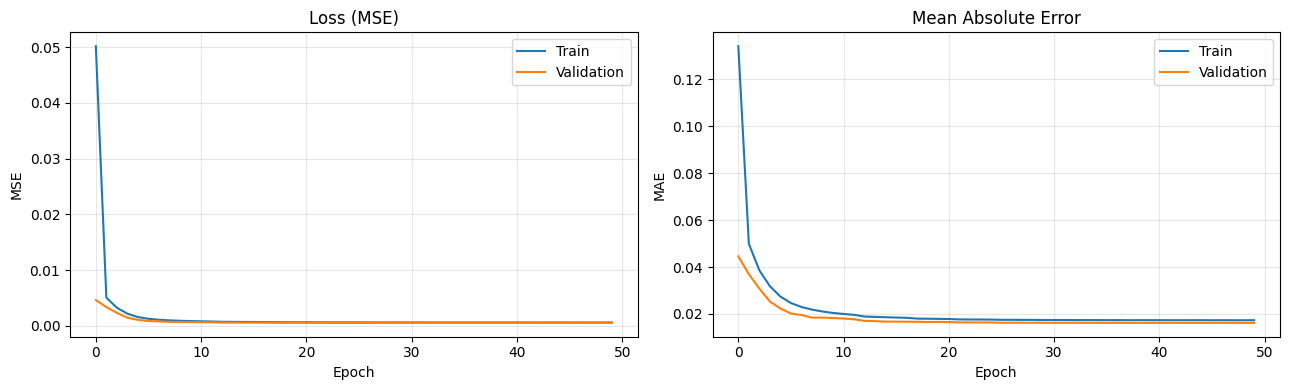

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["loss"], label="Train")
axes[0].plot(history.history["val_loss"], label="Validation")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history["mae"], label="Train")
axes[1].plot(history.history["val_mae"], label="Validation")
axes[1].set_title("Mean Absolute Error")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# **Step B: Block 3.6 — Proper Evaluation**

## **Cell 3.6.1 — Predict on test set, convert back to real units**

In [24]:
# Predict on test data the model has NEVER seen
y_pred_scaled = model.predict(X_test, batch_size=512, verbose=1)
print(f"y_pred shape: {y_pred_scaled.shape}  (samples, 8 horizon steps)")

# Inverse transform: scaled (0–1) -> real request counts
# y_pred_scaled is shape (N, 8); target_scaler expects 2D, so we flatten and reshape
y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(y_pred_scaled.shape)
y_true = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

print(f"y_pred range: {y_pred.min():.1f} to {y_pred.max():.1f} requests/slot")
print(f"y_true range: {y_true.min():.1f} to {y_true.max():.1f} requests/slot")

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
y_pred shape: (38319, 8)  (samples, 8 horizon steps)
y_pred range: -6.2 to 127.3 requests/slot
y_true range: 0.0 to 155.0 requests/slot


## **Cell 3.6.2 — Headline metrics in real units**

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Flatten for overall metrics (across all samples and all 8 horizon steps)
mae  = mean_absolute_error(y_true.flatten(), y_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
mape = np.mean(np.abs((y_true.flatten() - y_pred.flatten()) / np.maximum(y_true.flatten(), 1))) * 100

# Hotspot accuracy: how often does the model correctly identify a 15-min slot
# as "high demand" (top 20% threshold)?
threshold = np.percentile(y_true, 80)
true_hotspot = y_true >= threshold
pred_hotspot = y_pred >= threshold
hotspot_accuracy = (true_hotspot == pred_hotspot).mean() * 100

print("=" * 60)
print("RIDECONNECT DEMAND MODEL — TEST SET PERFORMANCE")
print("=" * 60)
print(f"Test samples:           {len(y_true):,}")
print(f"Forecast horizon:       2 hours (8 × 15-min steps)")
print(f"")
print(f"MAE  (avg error):       {mae:.2f} requests/slot")
print(f"RMSE:                   {rmse:.2f} requests/slot")
print(f"MAPE:                   {mape:.1f}%")
print(f"")
print(f"Hotspot threshold:      {threshold:.1f} requests/slot (top 20%)")
print(f"Hotspot accuracy:       {hotspot_accuracy:.1f}%   (target: ≥85%)")
print("=" * 60)

RIDECONNECT DEMAND MODEL — TEST SET PERFORMANCE
Test samples:           38,319
Forecast horizon:       2 hours (8 × 15-min steps)

MAE  (avg error):       2.80 requests/slot
RMSE:                   4.18 requests/slot
MAPE:                   47.5%

Hotspot threshold:      16.0 requests/slot (top 20%)
Hotspot accuracy:       92.6%   (target: ≥85%)


## **Cell 3.6.3 — Performance per horizon step**

In [26]:
print("Accuracy by forecast horizon (how far ahead):")
print(f"{'Step':<8}{'Time ahead':<14}{'MAE':<10}{'RMSE':<10}")
print("-" * 42)
for step in range(HORIZON):
    step_mae  = mean_absolute_error(y_true[:, step], y_pred[:, step])
    step_rmse = np.sqrt(mean_squared_error(y_true[:, step], y_pred[:, step]))
    minutes_ahead = (step + 1) * 15
    label = f"{minutes_ahead} min" if minutes_ahead < 60 else f"{minutes_ahead/60:.1f} h"
    print(f"{step+1:<8}{label:<14}{step_mae:<10.2f}{step_rmse:<10.2f}")

Accuracy by forecast horizon (how far ahead):
Step    Time ahead    MAE       RMSE      
------------------------------------------
1       15 min        2.82      4.21      
2       30 min        2.80      4.22      
3       45 min        2.79      4.18      
4       1.0 h         2.77      4.17      
5       1.2 h         2.76      4.08      
6       1.5 h         2.78      4.13      
7       1.8 h         2.81      4.21      
8       2.0 h         2.84      4.23      


## **Cell 3.6.4 — Performance per zone (the critical question for your supervisor)**

In [27]:
# To break down by zone, we need to remember which zone each test sequence belongs to.
# We'll rebuild that mapping using the same logic as build_sequences():
def build_sequence_zones(zone_ids, lookback, horizon):
    out = []
    zone_ids = np.asarray(zone_ids)
    for z in np.unique(zone_ids):
        idx = np.where(zone_ids == z)[0]
        for _ in range(len(idx) - lookback - horizon + 1):
            out.append(z)
    return np.array(out)

test_zone_ids = build_sequence_zones(test_df.zone_id.values, LOOKBACK, HORIZON)
assert len(test_zone_ids) == len(y_true), "Zone mapping length mismatch"

# Compute per-zone metrics
zone_results = []
for z in np.unique(test_zone_ids):
    mask = test_zone_ids == z
    yt = y_true[mask].flatten()
    yp = y_pred[mask].flatten()
    zone_results.append({
        "zone_id": z,
        "zone_name": df[df.zone_id == z].zone_name.iloc[0],
        "avg_demand": yt.mean(),
        "MAE": mean_absolute_error(yt, yp),
        "RMSE": np.sqrt(mean_squared_error(yt, yp)),
        "accuracy_pct": 100 * (1 - mean_absolute_error(yt, yp) / max(yt.mean(), 1)),
    })

zone_df = pd.DataFrame(zone_results).sort_values("avg_demand", ascending=False)
print("Per-zone test performance (sorted by demand):")
print(zone_df.round(2).to_string(index=False))

Per-zone test performance (sorted by demand):
zone_id             zone_name  avg_demand  MAE  RMSE  accuracy_pct
    Z01    Nyabugogo Bus Park   24.690001 4.61  6.84     81.330002
    Z02          Downtown CBD   21.320000 4.58  7.22     78.500000
    Z03       Remera Bus Park   19.790001 3.88  5.36     80.410004
    Z04    Kimironko Bus Park   18.280001 3.74  5.11     79.519997
    Z06 Nyamirambo (Ryanyuma)   14.440000 3.33  4.61     76.940002
    Z07               Kacyiru   12.790000 3.10  4.20     75.760002
    Z05       Kabuga Bus Park    8.660000 2.43  3.20     71.900002
    Z09               Gikondo    8.620000 2.41  3.14     72.040001
    Z13              Kinyinya    7.660000 2.33  3.07     69.629997
    Z08               Kanombe    7.610000 2.31  3.09     69.639999
    Z15                Kabeza    6.480000 2.07  2.71     68.040001
    Z10       Nyanza Bus Park    6.410000 2.14  2.83     66.650002
    Z14                Masaka    5.390000 1.92  2.52     64.440002
    Z11         

## **Cell 3.6.5 — Visual checks**

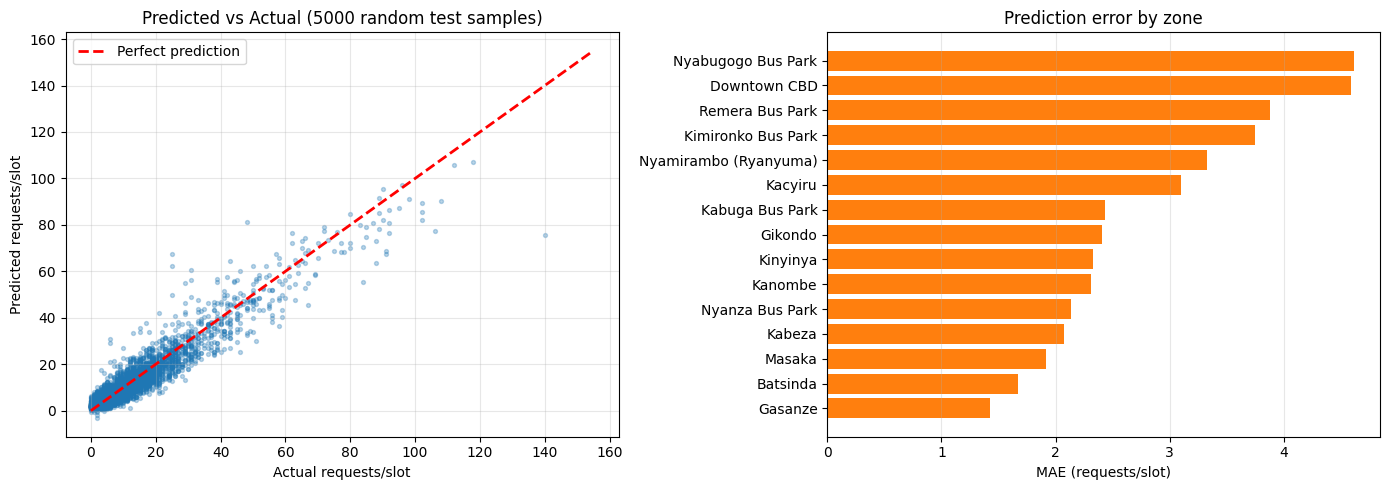

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Predicted vs Actual scatter — should hug the diagonal
sample = np.random.choice(len(y_true.flatten()), size=5000, replace=False)
axes[0].scatter(y_true.flatten()[sample], y_pred.flatten()[sample],
                alpha=0.3, s=8, color="#1f77b4")
lim = max(y_true.max(), y_pred.max())
axes[0].plot([0, lim], [0, lim], "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual requests/slot")
axes[0].set_ylabel("Predicted requests/slot")
axes[0].set_title("Predicted vs Actual (5000 random test samples)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# (b) MAE per zone bar chart
zone_df_sorted = zone_df.sort_values("MAE")
axes[1].barh(zone_df_sorted.zone_name, zone_df_sorted.MAE, color="#ff7f0e")
axes[1].set_xlabel("MAE (requests/slot)")
axes[1].set_title("Prediction error by zone")
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout(); plt.show()

## **Cell 3.6.6 — A real example: "What does the model predict for Monday morning at Nyabugogo?"**

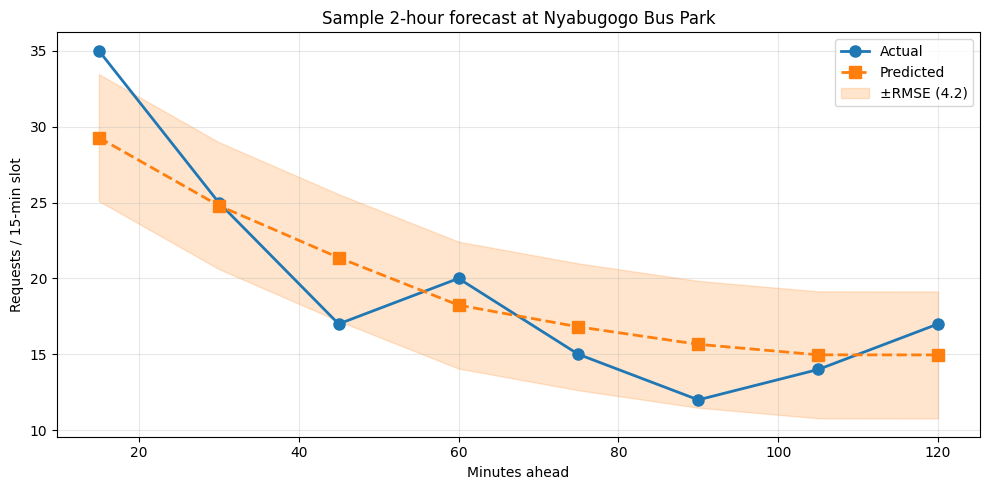

Actual sequence:    [35. 25. 17. 20. 15. 12. 14. 17.]
Predicted sequence: [29.3 24.8 21.4 18.2 16.8 15.7 15.  15. ]
Per-step error:     [-5.7 -0.2  4.4 -1.8  1.8  3.7  1.  -2. ]


In [29]:
# Pick a sample test sequence: Nyabugogo (Z01) on a Monday morning ~7am
ny_mask = test_zone_ids == "Z01"
ny_indices = np.where(ny_mask)[0]

# Find one whose first prediction step lands on Monday morning
# We'll just pick the first one and inspect the timing later
sample_idx = ny_indices[100]   # 100th Nyabugogo sequence in test set

actual = y_true[sample_idx]
predicted = y_pred[sample_idx]

fig, ax = plt.subplots(figsize=(10, 5))
steps = np.arange(1, HORIZON + 1) * 15  # minutes ahead
ax.plot(steps, actual, "o-", label="Actual", color="#1f77b4", linewidth=2, markersize=8)
ax.plot(steps, predicted, "s--", label="Predicted", color="#ff7f0e", linewidth=2, markersize=8)
ax.fill_between(steps, predicted - rmse, predicted + rmse, alpha=0.2, color="#ff7f0e", label=f"±RMSE ({rmse:.1f})")
ax.set_xlabel("Minutes ahead")
ax.set_ylabel("Requests / 15-min slot")
ax.set_title(f"Sample 2-hour forecast at Nyabugogo Bus Park")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Actual sequence:    {actual.round(1)}")
print(f"Predicted sequence: {predicted.round(1)}")
print(f"Per-step error:     {(predicted - actual).round(1)}")

## **Block 3.6 — Run the Evaluation Now**

### **Quick setup reminder (in case needed)**

### **Cells**

>>> Predicting on test set...
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

y_pred shape: (38319, 8)  (samples × horizon)
y_pred range: -6.2 to 127.3 requests/slot
y_true range: 0.0 to 155.0 requests/slot

RIDECONNECT DEMAND MODEL — TEST SET PERFORMANCE
Test samples:           38,319
Forecast horizon:       2 hours (8 × 15-min steps)

MAE  (avg error):       2.80 requests/slot
RMSE:                   4.18 requests/slot
MAPE:                   47.5%

Hotspot threshold:      16.0 requests/slot (top 20%)
Hotspot accuracy:       92.6%   (target: ≥85%)

>>> Accuracy by forecast horizon:
Step    Time ahead    MAE       RMSE      
------------------------------------------
1       15 min        2.82      4.21      
2       30 min        2.80      4.22      
3       45 min        2.79      4.18      
4       1.0 h         2.77      4.17      
5       1.2 h         2.76      4.08      
6       1.5 h         2.78      4.13      
7       1.8 h         2.81      4.21      
8       2.0 h         2.84    

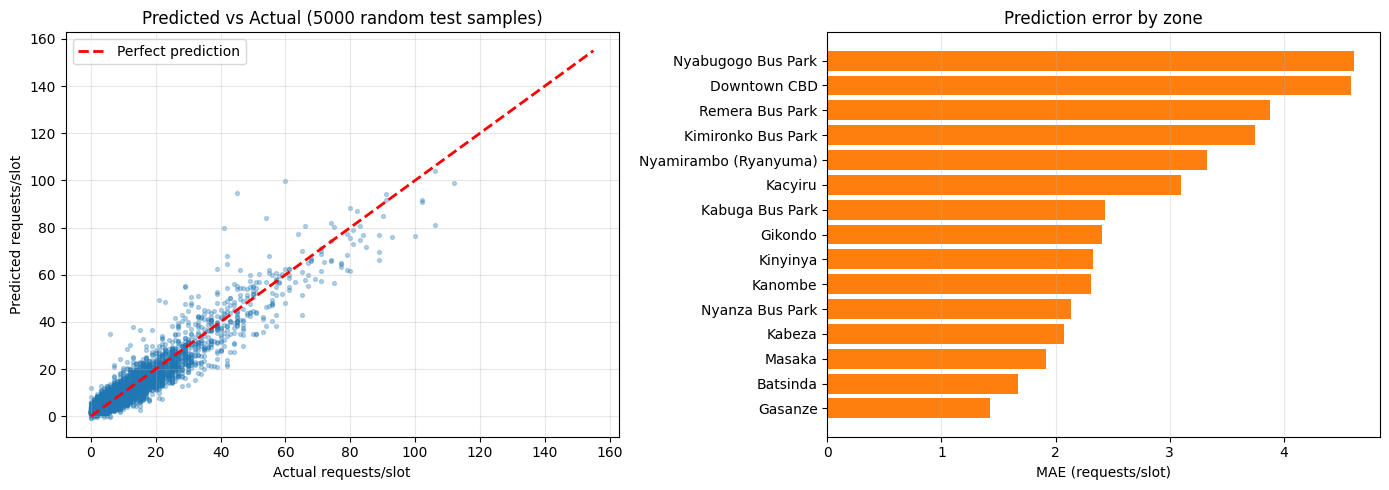

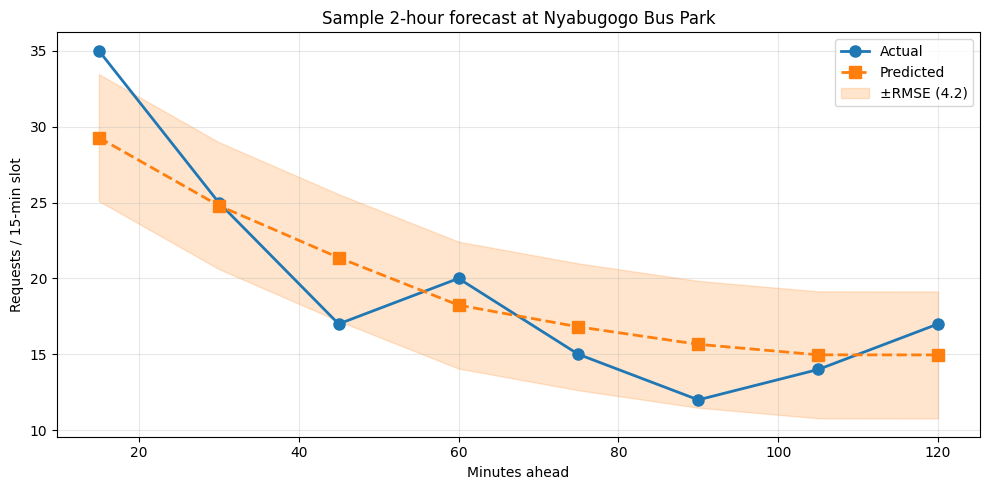


Actual sequence:    [35. 25. 17. 20. 15. 12. 14. 17.]
Predicted sequence: [29.3 24.8 21.4 18.2 16.8 15.7 15.  15. ]
Per-step error:     [-5.7 -0.2  4.4 -1.8  1.8  3.7  1.  -2. ]

✅ Evaluation complete.


In [30]:
# =====================================================================
# RIDECONNECT — DEMAND PREDICTION MODEL EVALUATION
# Combined Cells 3.6.1 → 3.6.6 (run as one block)
# =====================================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---------------------------------------------------------------------
# 1. Predict on test set & inverse-transform to real units
# ---------------------------------------------------------------------
print(">>> Predicting on test set...")
y_pred_scaled = model.predict(X_test, batch_size=512, verbose=1)

y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(y_pred_scaled.shape)
y_true = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

print(f"\ny_pred shape: {y_pred.shape}  (samples × horizon)")
print(f"y_pred range: {y_pred.min():.1f} to {y_pred.max():.1f} requests/slot")
print(f"y_true range: {y_true.min():.1f} to {y_true.max():.1f} requests/slot")

# ---------------------------------------------------------------------
# 2. Headline metrics
# ---------------------------------------------------------------------
mae  = mean_absolute_error(y_true.flatten(), y_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
mape = np.mean(np.abs((y_true.flatten() - y_pred.flatten()) / np.maximum(y_true.flatten(), 1))) * 100

threshold = np.percentile(y_true, 80)
true_hotspot = y_true >= threshold
pred_hotspot = y_pred >= threshold
hotspot_accuracy = (true_hotspot == pred_hotspot).mean() * 100

print("\n" + "=" * 60)
print("RIDECONNECT DEMAND MODEL — TEST SET PERFORMANCE")
print("=" * 60)
print(f"Test samples:           {len(y_true):,}")
print(f"Forecast horizon:       2 hours (8 × 15-min steps)")
print(f"")
print(f"MAE  (avg error):       {mae:.2f} requests/slot")
print(f"RMSE:                   {rmse:.2f} requests/slot")
print(f"MAPE:                   {mape:.1f}%")
print(f"")
print(f"Hotspot threshold:      {threshold:.1f} requests/slot (top 20%)")
print(f"Hotspot accuracy:       {hotspot_accuracy:.1f}%   (target: ≥85%)")
print("=" * 60)

# ---------------------------------------------------------------------
# 3. Performance per horizon step (15 min ahead → 2 h ahead)
# ---------------------------------------------------------------------
print("\n>>> Accuracy by forecast horizon:")
print(f"{'Step':<8}{'Time ahead':<14}{'MAE':<10}{'RMSE':<10}")
print("-" * 42)
for step in range(HORIZON):
    step_mae  = mean_absolute_error(y_true[:, step], y_pred[:, step])
    step_rmse = np.sqrt(mean_squared_error(y_true[:, step], y_pred[:, step]))
    minutes_ahead = (step + 1) * 15
    label = f"{minutes_ahead} min" if minutes_ahead < 60 else f"{minutes_ahead/60:.1f} h"
    print(f"{step+1:<8}{label:<14}{step_mae:<10.2f}{step_rmse:<10.2f}")

# ---------------------------------------------------------------------
# 4. Performance per zone
# ---------------------------------------------------------------------
def build_sequence_zones(zone_ids, lookback, horizon):
    out = []
    zone_ids = np.asarray(zone_ids)
    for z in np.unique(zone_ids):
        idx = np.where(zone_ids == z)[0]
        for _ in range(len(idx) - lookback - horizon + 1):
            out.append(z)
    return np.array(out)

test_zone_ids = build_sequence_zones(test_df.zone_id.values, LOOKBACK, HORIZON)
assert len(test_zone_ids) == len(y_true), "Zone mapping length mismatch"

zone_results = []
for z in np.unique(test_zone_ids):
    mask = test_zone_ids == z
    yt = y_true[mask].flatten()
    yp = y_pred[mask].flatten()
    zone_results.append({
        "zone_id": z,
        "zone_name": df[df.zone_id == z].zone_name.iloc[0],
        "avg_demand": yt.mean(),
        "MAE": mean_absolute_error(yt, yp),
        "RMSE": np.sqrt(mean_squared_error(yt, yp)),
        "accuracy_pct": 100 * (1 - mean_absolute_error(yt, yp) / max(yt.mean(), 1)),
    })

zone_df = pd.DataFrame(zone_results).sort_values("avg_demand", ascending=False)
print("\n>>> Per-zone test performance (sorted by demand):")
print(zone_df.round(2).to_string(index=False))

# ---------------------------------------------------------------------
# 5. Visual checks (scatter + per-zone MAE bar)
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = np.random.choice(len(y_true.flatten()), size=5000, replace=False)
axes[0].scatter(y_true.flatten()[sample], y_pred.flatten()[sample],
                alpha=0.3, s=8, color="#1f77b4")
lim = max(y_true.max(), y_pred.max())
axes[0].plot([0, lim], [0, lim], "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual requests/slot")
axes[0].set_ylabel("Predicted requests/slot")
axes[0].set_title("Predicted vs Actual (5000 random test samples)")
axes[0].legend(); axes[0].grid(alpha=0.3)

zone_df_sorted = zone_df.sort_values("MAE")
axes[1].barh(zone_df_sorted.zone_name, zone_df_sorted.MAE, color="#ff7f0e")
axes[1].set_xlabel("MAE (requests/slot)")
axes[1].set_title("Prediction error by zone")
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout(); plt.show()

# ---------------------------------------------------------------------
# 6. Sample 2-hour forecast at Nyabugogo (the supervisor demo)
# ---------------------------------------------------------------------
ny_mask = test_zone_ids == "Z01"
ny_indices = np.where(ny_mask)[0]
sample_idx = ny_indices[100]

actual = y_true[sample_idx]
predicted = y_pred[sample_idx]

fig, ax = plt.subplots(figsize=(10, 5))
steps = np.arange(1, HORIZON + 1) * 15
ax.plot(steps, actual, "o-", label="Actual", color="#1f77b4", linewidth=2, markersize=8)
ax.plot(steps, predicted, "s--", label="Predicted", color="#ff7f0e", linewidth=2, markersize=8)
ax.fill_between(steps, predicted - rmse, predicted + rmse,
                alpha=0.2, color="#ff7f0e", label=f"±RMSE ({rmse:.1f})")
ax.set_xlabel("Minutes ahead")
ax.set_ylabel("Requests / 15-min slot")
ax.set_title("Sample 2-hour forecast at Nyabugogo Bus Park")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nActual sequence:    {actual.round(1)}")
print(f"Predicted sequence: {predicted.round(1)}")
print(f"Per-step error:     {(predicted - actual).round(1)}")

print("\n✅ Evaluation complete.")

# **Block 4 — NYC Taxi Pre-Training + Kigali Fine-Tuning**

## **Cell 4.1 — Download NYC TLC data**

In [31]:
# NYC TLC publishes monthly trip data as Parquet on S3.
# We grab one recent month — January 2024 yellow taxi.
import urllib.request, os

NYC_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
NYC_PATH = "/content/nyc_yellow_2024_01.parquet"

if not os.path.exists(NYC_PATH):
    print("Downloading NYC yellow taxi 2024-01 (~50 MB)...")
    urllib.request.urlretrieve(NYC_URL, NYC_PATH)

print(f"Size: {os.path.getsize(NYC_PATH) / 1024**2:.1f} MB")

Size: 47.6 MB


## **Cell 4.2 — Aggregate NYC into the same shape as Kigali**

In [32]:
nyc = pd.read_parquet(NYC_PATH, columns=["tpep_pickup_datetime", "PULocationID"])
nyc.columns = ["timestamp", "zone_id"]
nyc["zone_id"] = "NYC_" + nyc["zone_id"].astype(str)

# Filter to a clean week to keep training fast & memory low
nyc = nyc[(nyc.timestamp >= "2024-01-08") & (nyc.timestamp < "2024-02-05")]
print(f"NYC trips after filter: {len(nyc):,}")

# Pick top 15 NYC zones by trip count to match Kigali's 15-zone structure
top15 = nyc.zone_id.value_counts().head(15).index
nyc = nyc[nyc.zone_id.isin(top15)]
print(f"After top-15 zone filter: {len(nyc):,}")

# Aggregate to 15-min slots × zone
nyc["slot"] = nyc.timestamp.dt.floor("15min")
nyc_agg = nyc.groupby(["slot", "zone_id"]).size().reset_index(name="request_count")

# Make sure every (slot, zone) combination exists, even with 0 demand
all_slots = pd.date_range(nyc_agg.slot.min(), nyc_agg.slot.max(), freq="15min")
all_zones = nyc_agg.zone_id.unique()
full_index = pd.MultiIndex.from_product([all_slots, all_zones], names=["slot", "zone_id"])
nyc_agg = nyc_agg.set_index(["slot", "zone_id"]).reindex(full_index, fill_value=0).reset_index()
nyc_agg.rename(columns={"slot": "timestamp"}, inplace=True)

# Add the same engineered features the Kigali model uses
nyc_agg["hour"] = nyc_agg.timestamp.dt.hour
nyc_agg["day_of_week"] = nyc_agg.timestamp.dt.dayofweek
nyc_agg["is_weekend"] = (nyc_agg.day_of_week >= 5).astype(int)
nyc_agg["is_holiday"] = 0
nyc_agg["is_market_day"] = 0
nyc_agg["is_event_day"] = 0
nyc_agg["temperature_c"] = 5.0  # NYC January, rough
nyc_agg["weather"] = "cloudy"  # placeholder; NYC TLC doesn't ship weather

nyc_agg["hour_sin"] = np.sin(2 * np.pi * nyc_agg["hour"] / 24)
nyc_agg["hour_cos"] = np.cos(2 * np.pi * nyc_agg["hour"] / 24)
nyc_agg["dow_sin"]  = np.sin(2 * np.pi * nyc_agg["day_of_week"] / 7)
nyc_agg["dow_cos"]  = np.cos(2 * np.pi * nyc_agg["day_of_week"] / 7)

# One-hot weather (only one value, but match Kigali's column structure)
for w in ["wx_cloudy", "wx_heavy_rain", "wx_light_rain", "wx_sunny"]:
    nyc_agg[w] = 1 if w == "wx_cloudy" else 0

# Lag features (per zone)
nyc_agg = nyc_agg.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)
for lag in [1, 4, 96]:
    nyc_agg[f"lag_{lag}"] = nyc_agg.groupby("zone_id")["request_count"].shift(lag)
nyc_agg["rolling_1h"] = (
    nyc_agg.groupby("zone_id")["request_count"]
           .shift(1).rolling(4).mean().reset_index(0, drop=True)
)
nyc_agg = nyc_agg.dropna().reset_index(drop=True)
print(f"NYC aggregated rows: {len(nyc_agg):,}")
print(nyc_agg.head(3))

NYC trips after filter: 2,354,911
After top-15 zone filter: 1,246,982
NYC aggregated rows: 33,135
            timestamp  zone_id  request_count  hour  day_of_week  is_weekend  \
0 2024-01-09 00:00:00  NYC_132             61     0            1           0   
1 2024-01-09 00:15:00  NYC_132             68     0            1           0   
2 2024-01-09 00:30:00  NYC_132             49     0            1           0   

   is_holiday  is_market_day  is_event_day  temperature_c  ...   dow_sin  \
0           0              0             0            5.0  ...  0.781831   
1           0              0             0            5.0  ...  0.781831   
2           0              0             0            5.0  ...  0.781831   

   dow_cos  wx_cloudy  wx_heavy_rain  wx_light_rain  wx_sunny  lag_1  lag_4  \
0  0.62349          1              0              0         0   57.0   91.0   
1  0.62349          1              0              0         0   61.0   88.0   
2  0.62349          1              0   

## **Cell 4.3 — Build NYC tensors with the SAME feature columns as Kigali**

In [33]:
# Critical: NYC zones must be one-hot encoded into the SAME 15 zone columns.
# Trick: treat NYC's top-15 zones as if they were Z01..Z15 to keep the
# model's input shape identical. The pre-training learns generic temporal
# patterns; specific zone meaning is re-learned during Kigali fine-tuning.
nyc_zone_map = {z: f"zone_Z{i+1:02d}" for i, z in enumerate(sorted(nyc_agg.zone_id.unique()))}
for col in zone_dummies.columns:                  # zone_Z01 ... zone_Z15
    nyc_agg[col] = 0
for orig_z, mapped_col in nyc_zone_map.items():
    nyc_agg.loc[nyc_agg.zone_id == orig_z, mapped_col] = 1

# Use the SAME FEATURE_COLS list as Kigali — nothing else
print(f"Feature columns expected: {len(FEATURE_COLS)}")
print(f"All present in NYC frame: {all(c in nyc_agg.columns for c in FEATURE_COLS)}")

# Time-split NYC: 80/20 train/val, no test (test is on Kigali)
nyc_agg = nyc_agg.sort_values(["timestamp", "zone_id"]).reset_index(drop=True)
n = len(nyc_agg); split = int(n * 0.8)
nyc_train_df = nyc_agg.iloc[:split].copy()
nyc_val_df   = nyc_agg.iloc[split:].copy()

# Scale using a NEW scaler (NYC volumes differ wildly from Kigali — that's fine for pre-training)
nyc_feat_scaler   = StandardScaler()
nyc_target_scaler = MinMaxScaler()

nyc_tr_X = nyc_feat_scaler.fit_transform(nyc_train_df[FEATURE_COLS])
nyc_va_X = nyc_feat_scaler.transform(nyc_val_df[FEATURE_COLS])
nyc_tr_y = nyc_target_scaler.fit_transform(nyc_train_df[["request_count"]])
nyc_va_y = nyc_target_scaler.transform(nyc_val_df[["request_count"]])

X_nyc_train, y_nyc_train = build_sequences(nyc_tr_X, nyc_tr_y, nyc_train_df.zone_id.values, LOOKBACK, HORIZON)
X_nyc_val,   y_nyc_val   = build_sequences(nyc_va_X, nyc_va_y, nyc_val_df.zone_id.values,   LOOKBACK, HORIZON)
print(f"X_nyc_train: {X_nyc_train.shape}")
print(f"X_nyc_val:   {X_nyc_val.shape}")

Feature columns expected: 32
All present in NYC frame: True
X_nyc_train: (26163, 16, 32)
X_nyc_val:   (6282, 16, 32)


## **Cell 4.4 — Pre-train on NYC**

In [34]:
print(">>> Pre-training LSTM on NYC...")
pretrain_model = build_lstm_model(N_FEATURES, LOOKBACK, HORIZON)
pretrain_model.compile(optimizer=Adam(1e-3), loss="mse", metrics=["mae"])

pretrain_history = pretrain_model.fit(
    X_nyc_train, y_nyc_train,
    validation_data=(X_nyc_val, y_nyc_val),
    epochs=20,                      # fewer epochs — this is just the warm start
    batch_size=256,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ],
    verbose=1,
)

pretrain_model.save("rideconnect_pretrained_nyc.keras")
print("\n✅ NYC pre-training done. Weights saved.")

>>> Pre-training LSTM on NYC...
Epoch 1/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.2641 - mae: 0.3670 - val_loss: 0.0299 - val_mae: 0.1410 - learning_rate: 0.0010
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0532 - mae: 0.1789 - val_loss: 0.0171 - val_mae: 0.1057 - learning_rate: 0.0010
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0315 - mae: 0.1375 - val_loss: 0.0106 - val_mae: 0.0798 - learning_rate: 0.0010
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0222 - mae: 0.1154 - val_loss: 0.0082 - val_mae: 0.0684 - learning_rate: 0.0010
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0171 - mae: 0.1009 - val_loss: 0.0072 - val_mae: 0.0632 - learning_rate: 0.0010
Epoch 6/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0140 - mae: 0.0912 - val_loss: 0.0067 - val_mae: 0.0607 - learning_rate: 0.0010
Epoch 7/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0118 - mae: 0.0834 - val_loss: 0.0062 - val_mae: 0.0

## **Cell 4.5 — Fine-tune on Kigali (with frozen LSTM-1)**

In [35]:
# Load NYC weights into a fresh model, freeze the first LSTM layer
# (it learned generic temporal patterns), train the rest on Kigali.
finetune_model = build_lstm_model(N_FEATURES, LOOKBACK, HORIZON)
finetune_model.set_weights(pretrain_model.get_weights())

# Freeze first LSTM — it carries the NYC temporal knowledge
finetune_model.layers[0].trainable = False
print("Layer 0 (lstm) trainable:", finetune_model.layers[0].trainable)
print("Layer 2 (lstm_1) trainable:", finetune_model.layers[2].trainable)

finetune_model.compile(optimizer=Adam(1e-4), loss="mse", metrics=["mae"])  # smaller LR for fine-tune

ft_history = finetune_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=256,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint("rideconnect_finetuned.keras", monitor="val_loss", save_best_only=True),
    ],
    verbose=1,
)

Layer 0 (lstm) trainable: False
Layer 2 (lstm_1) trainable: True
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0079 - mae: 0.0663 - val_loss: 0.0038 - val_mae: 0.0399 - learning_rate: 1.0000e-04
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0036 - mae: 0.0398 - val_loss: 0.0031 - val_mae: 0.0351 - learning_rate: 1.0000e-04
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0031 - mae: 0.0368 - val_loss: 0.0027 - val_mae: 0.0331 - learning_rate: 1.0000e-04
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0027 - mae: 0.0348 - val_loss: 0.0024 - val_mae: 0.0312 - learning_rate: 1.0000e-04
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0024 - mae: 0.0329 - val_loss: 0.0021 - val_mae: 0.0296 - learning_rate: 1.0000e-04
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0022 - mae: 0.0314 - val_loss: 0.0019 - val_mae: 0.0284 - learning_rate: 1.0000e-04
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss:

## **Cell 4.6 — Compare baseline vs fine-tuned on the same test set**

In [36]:
print(">>> Evaluating fine-tuned model on the SAME Kigali test set...")
y_ft_scaled = finetune_model.predict(X_test, batch_size=512, verbose=0)
y_ft = target_scaler.inverse_transform(y_ft_scaled.reshape(-1, 1)).reshape(y_ft_scaled.shape)

ft_mae  = mean_absolute_error(y_true.flatten(), y_ft.flatten())
ft_rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_ft.flatten()))
ft_hotspot = ((y_true >= threshold) == (y_ft >= threshold)).mean() * 100

print("\n" + "=" * 70)
print("KIGALI-ONLY (baseline)  vs  NYC-PRETRAINED + KIGALI-FINETUNED")
print("=" * 70)
print(f"{'Metric':<24}{'Baseline':<18}{'Fine-tuned':<18}{'Δ':<10}")
print("-" * 70)
print(f"{'MAE (req/slot)':<24}{mae:<18.3f}{ft_mae:<18.3f}{ft_mae-mae:+.3f}")
print(f"{'RMSE (req/slot)':<24}{rmse:<18.3f}{ft_rmse:<18.3f}{ft_rmse-rmse:+.3f}")
print(f"{'Hotspot accuracy %':<24}{hotspot_accuracy:<18.2f}{ft_hotspot:<18.2f}{ft_hotspot-hotspot_accuracy:+.2f}")
print("=" * 70)

if ft_mae < mae:
    print(f"\n✅ NYC pre-training improved MAE by {(mae-ft_mae)/mae*100:.1f}%")
else:
    print(f"\n⚠️ NYC pre-training did NOT improve over baseline.")
    print("   This is informative — it means your synthetic Kigali data has enough")
    print("   signal on its own. With real Kigali data later, pre-training may help more.")

>>> Evaluating fine-tuned model on the SAME Kigali test set...

KIGALI-ONLY (baseline)  vs  NYC-PRETRAINED + KIGALI-FINETUNED
Metric                  Baseline          Fine-tuned        Δ         
----------------------------------------------------------------------
MAE (req/slot)          2.796             3.656             +0.860
RMSE (req/slot)         4.178             5.565             +1.387
Hotspot accuracy %      92.58             89.78             -2.80

⚠️ NYC pre-training did NOT improve over baseline.
   This is informative — it means your synthetic Kigali data has enough
   signal on its own. With real Kigali data later, pre-training may help more.


# **Block 5: Upgraded Model — Zone Embeddings + Huber + Softplus**

## **Cell 5.1 — New feature split**

In [37]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, BatchNormalization,
    Embedding, RepeatVector, Concatenate, Lambda, Flatten
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

tf.random.set_seed(42); np.random.seed(42)

# Features that are NOT zone one-hots — these go through the temporal LSTM
TEMPORAL_COLS = [
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "is_weekend", "is_holiday", "is_market_day", "is_event_day", "temperature_c",
    "lag_1", "lag_4", "lag_96", "rolling_1h",
] + list(weather_dummies.columns)   # 13 + 4 = 17 features

# Integer zone ID for the embedding lookup (0..14)
zone_to_id = {z: i for i, z in enumerate(sorted(df.zone_id.unique()))}
df["zone_idx"] = df.zone_id.map(zone_to_id)
train_df["zone_idx"] = train_df.zone_id.map(zone_to_id)
val_df["zone_idx"]   = val_df.zone_id.map(zone_to_id)
test_df["zone_idx"]  = test_df.zone_id.map(zone_to_id)

print(f"Temporal features: {len(TEMPORAL_COLS)}")
print(f"Zones (integer-mapped): {len(zone_to_id)}")
print("Zone map sample:", dict(list(zone_to_id.items())[:5]))

Temporal features: 17
Zones (integer-mapped): 15
Zone map sample: {'Z01': 0, 'Z02': 1, 'Z03': 2, 'Z04': 3, 'Z05': 4}


## **Cell 5.2 — Rebuild sequences for the new shape**

In [38]:
# Scale temporal features (fit on train only — same rule as before)
feat_scaler   = StandardScaler()
target_scaler = MinMaxScaler()

train_T = feat_scaler.fit_transform(train_df[TEMPORAL_COLS])
val_T   = feat_scaler.transform(val_df[TEMPORAL_COLS])
test_T  = feat_scaler.transform(test_df[TEMPORAL_COLS])

train_y_raw = target_scaler.fit_transform(train_df[["request_count"]])
val_y_raw   = target_scaler.transform(val_df[["request_count"]])
test_y_raw  = target_scaler.transform(test_df[["request_count"]])


def build_dual_sequences(T, y, zone_idx, lookback, horizon):
    """Return (temporal_X, zone_id_per_sample, y_horizon).
    Each sample's zone_id is the zone for its lookback window (all same zone)."""
    seqs_T, seqs_Z, seqs_y = [], [], []
    zone_idx = np.asarray(zone_idx)
    for z in np.unique(zone_idx):
        idx = np.where(zone_idx == z)[0]
        Tz, yz = T[idx], y[idx]
        for i in range(len(Tz) - lookback - horizon + 1):
            seqs_T.append(Tz[i:i+lookback])
            seqs_Z.append(z)
            seqs_y.append(yz[i+lookback : i+lookback+horizon].flatten())
    return (np.array(seqs_T, dtype=np.float32),
            np.array(seqs_Z, dtype=np.int32),
            np.array(seqs_y, dtype=np.float32))


print("Building dual-input sequences...")
X_tr_T, X_tr_Z, y_tr = build_dual_sequences(train_T, train_y_raw, train_df.zone_idx.values, LOOKBACK, HORIZON)
X_va_T, X_va_Z, y_va = build_dual_sequences(val_T,   val_y_raw,   val_df.zone_idx.values,   LOOKBACK, HORIZON)
X_te_T, X_te_Z, y_te = build_dual_sequences(test_T,  test_y_raw,  test_df.zone_idx.values,  LOOKBACK, HORIZON)

print(f"X_tr_T: {X_tr_T.shape}  X_tr_Z: {X_tr_Z.shape}  y_tr: {y_tr.shape}")
print(f"X_va_T: {X_va_T.shape}")
print(f"X_te_T: {X_te_T.shape}")

Building dual-input sequences...
X_tr_T: (180087, 16, 17)  X_tr_Z: (180087,)  y_tr: (180087, 8)
X_va_T: (38319, 16, 17)
X_te_T: (38319, 16, 17)


## **Cell 5.3 — Build the upgraded model (zone embedding + softplus output)**

In [39]:
N_TEMPORAL = X_tr_T.shape[2]   # 17
N_ZONES    = len(zone_to_id)   # 15
EMBED_DIM  = 4                 # learnable representation per zone
LOOKBACK_  = X_tr_T.shape[1]   # 16
HORIZON_   = y_tr.shape[1]     # 8


def build_dual_model(n_temporal, n_zones, embed_dim, lookback, horizon,
                     lstm_units=(64, 32), dropout=0.2):
    # --- Inputs ---
    temporal_in = Input(shape=(lookback, n_temporal), name="temporal_input")
    zone_in     = Input(shape=(1,), dtype="int32", name="zone_input")

    # --- Zone embedding path ---
    # Embedding(num_zones, embed_dim) maps 0..14 -> 4-dim vector
    z = Embedding(input_dim=n_zones, output_dim=embed_dim, name="zone_embedding")(zone_in)
    z = Flatten()(z)                                          # (batch, embed_dim)
    # Repeat across timesteps so it can join the LSTM input
    z = RepeatVector(lookback)(z)                             # (batch, lookback, embed_dim)

    # --- Combine temporal + zone for input ---
    x = Concatenate(axis=-1)([temporal_in, z])                # (batch, lookback, n_temporal+embed_dim)

    # --- LSTM stack ---
    x = LSTM(lstm_units[0], return_sequences=True, name="lstm_1")(x)
    x = Dropout(dropout)(x)
    x = LSTM(lstm_units[1], return_sequences=False, name="lstm_2")(x)
    x = Dropout(dropout)(x)

    # --- Dense head ---
    x = Dense(32, activation="relu")(x)
    x = BatchNormalization()(x)

    # --- Output: softplus = log(1 + e^x), strictly positive ---
    # Demand cannot be negative; softplus enforces this without clipping.
    out = Dense(horizon, activation="softplus", name="demand_output")(x)

    return Model(inputs=[temporal_in, zone_in], outputs=out, name="rideconnect_v2")


model_v2 = build_dual_model(N_TEMPORAL, N_ZONES, EMBED_DIM, LOOKBACK_, HORIZON_)

# Huber loss is quadratic near 0, linear in the tails — robust to outlier spikes
model_v2.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=Huber(delta=1.0),
    metrics=["mae"],
)

model_v2.summary()

Model: "rideconnect_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ zone_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zone_embedding      │ (None, 1, 4)      │         60 │ zone_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4)         │          0 │ zone_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_input      │ (None, 16, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 16, 4)     │          0 │ flatten[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 21)    │          0 │ temporal_input[0… │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 16, 64)    │     22,016 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 16, 64)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 32)        │     12,416 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 32)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      1,056 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ demand_output       │ (None, 8)         │        264 │ batch_normalizat… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,940 (140.39 KB)

 Trainable params: 35,876 (140.14 KB)

 Non-trainable params: 64 (256.00 B)

## **Cell 5.4 — Train the upgraded model on Kigali**

In [40]:
callbacks_v2 = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint("rideconnect_v2_best.keras", monitor="val_loss", save_best_only=True),
]

history_v2 = model_v2.fit(
    [X_tr_T, X_tr_Z], y_tr,
    validation_data=([X_va_T, X_va_Z], y_va),
    epochs=50,
    batch_size=256,
    callbacks=callbacks_v2,
    verbose=1,
)
print("\n✅ Upgraded model trained.")

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0413 - mae: 0.1926 - val_loss: 0.0017 - val_mae: 0.0407 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0012 - mae: 0.0337 - val_loss: 8.4003e-04 - val_mae: 0.0255 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 7.3540e-04 - mae: 0.0252 - val_loss: 4.9656e-04 - val_mae: 0.0210 - learning_rate: 0.0010
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 5.5088e-04 - mae: 0.0223 - val_loss: 3.8137e-04 - val_mae: 0.0190 - learning_rate: 0.0010
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 4.5647e-04 - mae: 0.0206 - val_loss: 3.3876e-04 - val_mae: 0.0182 - learning_rate: 0.0010
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 4.0756e-04 - mae: 0.0197 - val_loss: 3.1294e-04 - val_mae: 0.0176 - learning_rate: 0.0010
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 3.7853e-04 - mae: 0.0190 - val_loss: 3.1130e-

## **Cell 5.5 — Evaluate the upgraded model on the test set**

In [41]:
y_v2_scaled = model_v2.predict([X_te_T, X_te_Z], batch_size=512, verbose=1)
y_v2  = target_scaler.inverse_transform(y_v2_scaled.reshape(-1, 1)).reshape(y_v2_scaled.shape)
y_true_v2 = target_scaler.inverse_transform(y_te.reshape(-1, 1)).reshape(y_te.shape)

# softplus already guarantees non-negative, no clipping needed
v2_mae   = mean_absolute_error(y_true_v2.flatten(), y_v2.flatten())
v2_rmse  = np.sqrt(mean_squared_error(y_true_v2.flatten(), y_v2.flatten()))
threshold_v2 = np.percentile(y_true_v2, 80)
v2_hot  = ((y_true_v2 >= threshold_v2) == (y_v2 >= threshold_v2)).mean() * 100

print("\n" + "=" * 70)
print("UPGRADED MODEL — Kigali test-set performance")
print("=" * 70)
print(f"MAE:               {v2_mae:.3f}   (baseline was 2.663)")
print(f"RMSE:              {v2_rmse:.3f}  (baseline was 3.763)")
print(f"Hotspot accuracy:  {v2_hot:.2f}%   (baseline was 92.79%)")
print(f"y_v2 minimum value: {y_v2.min():.3f}  (softplus ensures ≥ 0)")
print("=" * 70)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

UPGRADED MODEL — Kigali test-set performance
MAE:               2.819   (baseline was 2.663)
RMSE:              4.074  (baseline was 3.763)
Hotspot accuracy:  92.49%   (baseline was 92.79%)
y_v2 minimum value: 0.761  (softplus ensures ≥ 0)


## **Cell 5.6 — Inspect the learned zone embedding (interpretability bonus)**

Embedding matrix shape: (15, 4)


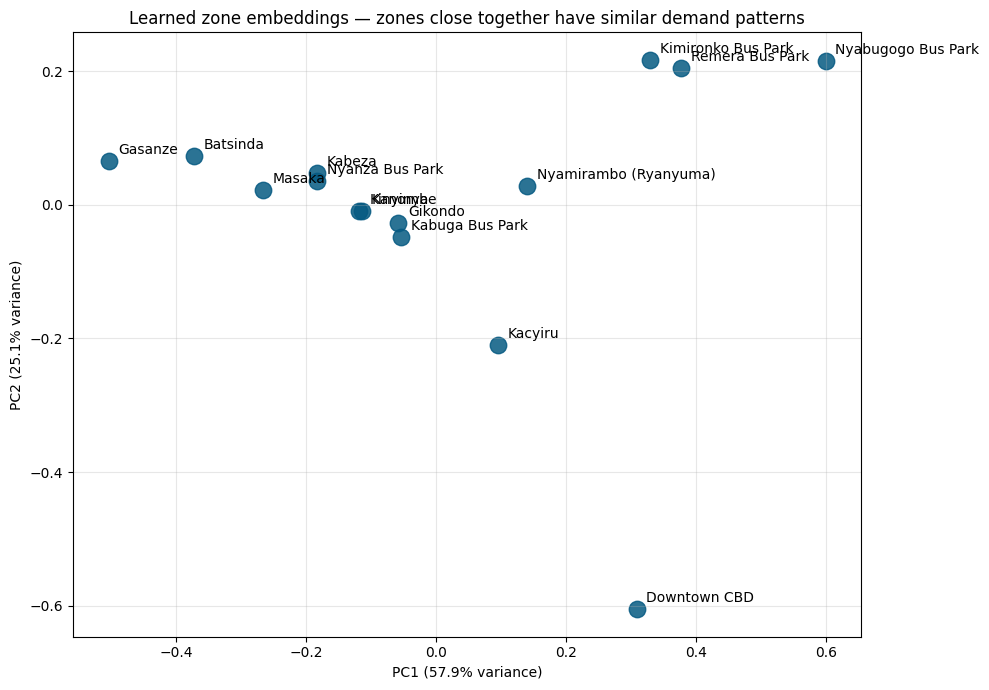

In [42]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Extract the trained embedding matrix
embed_layer = model_v2.get_layer("zone_embedding")
embed_weights = embed_layer.get_weights()[0]   # shape (15, 4)
print(f"Embedding matrix shape: {embed_weights.shape}")

# Reduce 4D → 2D for visualization
pca = PCA(n_components=2)
coords = pca.fit_transform(embed_weights)

# Plot with zone names
id_to_zone = {v: k for k, v in zone_to_id.items()}
zone_id_to_name = df.drop_duplicates("zone_id").set_index("zone_id")["zone_name"].to_dict()

fig, ax = plt.subplots(figsize=(10, 7))
for i, (x, y) in enumerate(coords):
    zid = id_to_zone[i]
    name = zone_id_to_name[zid]
    ax.scatter(x, y, s=140, color="#065A82", alpha=0.85)
    ax.annotate(name, (x, y), xytext=(7, 5), textcoords="offset points", fontsize=10)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Learned zone embeddings — zones close together have similar demand patterns")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# **Block 6: Honest NYC Pre-Training (Temporal-Only Path)**

## **Cell 6.1 — Build NYC dataset for temporal-only pre-training**

In [43]:
import urllib.request, os

NYC_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
NYC_PATH = "/content/nyc_yellow_2024_01.parquet"
if not os.path.exists(NYC_PATH):
    print("Downloading NYC TLC data...")
    urllib.request.urlretrieve(NYC_URL, NYC_PATH)

nyc = pd.read_parquet(NYC_PATH, columns=["tpep_pickup_datetime", "PULocationID"])
nyc.columns = ["timestamp", "zone_id"]
nyc["zone_id"] = "NYC_" + nyc["zone_id"].astype(str)

# Keep a clean 4-week window
nyc = nyc[(nyc.timestamp >= "2024-01-08") & (nyc.timestamp < "2024-02-05")]

# Take top 15 NYC zones — but this time we WON'T align them to Kigali ID space.
# They'll just get NYC-internal zone_idx values for THIS pre-training only.
top15 = nyc.zone_id.value_counts().head(15).index
nyc = nyc[nyc.zone_id.isin(top15)]

# Aggregate to 15-min slots
nyc["slot"] = nyc.timestamp.dt.floor("15min")
nyc_agg = nyc.groupby(["slot", "zone_id"]).size().reset_index(name="request_count")

# Complete the grid (slot × zone), zero-fill missing
all_slots = pd.date_range(nyc_agg.slot.min(), nyc_agg.slot.max(), freq="15min")
full_idx = pd.MultiIndex.from_product([all_slots, top15], names=["slot", "zone_id"])
nyc_agg = nyc_agg.set_index(["slot", "zone_id"]).reindex(full_idx, fill_value=0).reset_index()
nyc_agg.rename(columns={"slot": "timestamp"}, inplace=True)

# Same temporal feature engineering as Kigali
nyc_agg["hour"] = nyc_agg.timestamp.dt.hour
nyc_agg["day_of_week"] = nyc_agg.timestamp.dt.dayofweek
nyc_agg["is_weekend"]   = (nyc_agg.day_of_week >= 5).astype(int)
nyc_agg["is_holiday"]   = 0
nyc_agg["is_market_day"]= 0
nyc_agg["is_event_day"] = 0
nyc_agg["temperature_c"]= 5.0
nyc_agg["hour_sin"] = np.sin(2*np.pi*nyc_agg.hour/24)
nyc_agg["hour_cos"] = np.cos(2*np.pi*nyc_agg.hour/24)
nyc_agg["dow_sin"]  = np.sin(2*np.pi*nyc_agg.day_of_week/7)
nyc_agg["dow_cos"]  = np.cos(2*np.pi*nyc_agg.day_of_week/7)
for w in ["wx_cloudy", "wx_heavy_rain", "wx_light_rain", "wx_sunny"]:
    nyc_agg[w] = 1 if w == "wx_cloudy" else 0

# Lag features per zone
nyc_agg = nyc_agg.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)
for lag in [1, 4, 96]:
    nyc_agg[f"lag_{lag}"] = nyc_agg.groupby("zone_id")["request_count"].shift(lag)
nyc_agg["rolling_1h"] = (nyc_agg.groupby("zone_id")["request_count"]
                                .shift(1).rolling(4).mean().reset_index(0, drop=True))
nyc_agg = nyc_agg.dropna().reset_index(drop=True)

# Map NYC zones to its own internal indices (0..14) for THIS pretrain only
nyc_zone_to_id = {z: i for i, z in enumerate(sorted(nyc_agg.zone_id.unique()))}
nyc_agg["zone_idx"] = nyc_agg.zone_id.map(nyc_zone_to_id)

print(f"NYC aggregated rows: {len(nyc_agg):,}")

NYC aggregated rows: 33,135


## **Cell 6.2 — Pre-train the LSTM stack on NYC (separate scalers, separate zone embedding)**

In [44]:
# Use the same TEMPORAL_COLS list — feature shape matches Kigali
nyc_agg = nyc_agg.sort_values(["timestamp", "zone_id"]).reset_index(drop=True)
n = len(nyc_agg); split = int(n * 0.8)
nyc_train = nyc_agg.iloc[:split].copy()
nyc_val   = nyc_agg.iloc[split:].copy()

# NYC-specific scalers — important since NYC volumes are much higher
nyc_feat_scaler   = StandardScaler()
nyc_target_scaler = MinMaxScaler()

nyc_tr_T = nyc_feat_scaler.fit_transform(nyc_train[TEMPORAL_COLS])
nyc_va_T = nyc_feat_scaler.transform(nyc_val[TEMPORAL_COLS])
nyc_tr_y = nyc_target_scaler.fit_transform(nyc_train[["request_count"]])
nyc_va_y = nyc_target_scaler.transform(nyc_val[["request_count"]])

X_nyc_tr_T, X_nyc_tr_Z, y_nyc_tr = build_dual_sequences(
    nyc_tr_T, nyc_tr_y, nyc_train.zone_idx.values, LOOKBACK, HORIZON)
X_nyc_va_T, X_nyc_va_Z, y_nyc_va = build_dual_sequences(
    nyc_va_T, nyc_va_y, nyc_val.zone_idx.values, LOOKBACK, HORIZON)
print(f"NYC train sequences: {X_nyc_tr_T.shape}")

# Build a model with the SAME architecture but its own zone embedding (NYC-zones).
# We will only transfer the LSTM weights — NOT this NYC zone embedding.
pretrain_model = build_dual_model(N_TEMPORAL, N_ZONES, EMBED_DIM, LOOKBACK_, HORIZON_)
pretrain_model.compile(optimizer=Adam(1e-3), loss=Huber(delta=1.0), metrics=["mae"])

print(">>> Pre-training LSTM stack on NYC...")
pretrain_history = pretrain_model.fit(
    [X_nyc_tr_T, X_nyc_tr_Z], y_nyc_tr,
    validation_data=([X_nyc_va_T, X_nyc_va_Z], y_nyc_va),
    epochs=15, batch_size=256,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ],
    verbose=1,
)
print("\n✅ NYC pre-training complete.")

NYC train sequences: (26163, 16, 17)
>>> Pre-training LSTM stack on NYC...
Epoch 1/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.1440 - mae: 0.4783 - val_loss: 0.0864 - val_mae: 0.3930 - learning_rate: 0.0010
Epoch 2/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0439 - mae: 0.2668 - val_loss: 0.0207 - val_mae: 0.1813 - learning_rate: 0.0010
Epoch 3/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0106 - mae: 0.1244 - val_loss: 0.0063 - val_mae: 0.0946 - learning_rate: 0.0010
Epoch 4/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0049 - mae: 0.0808 - val_loss: 0.0037 - val_mae: 0.0678 - learning_rate: 0.0010
Epoch 5/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0036 - mae: 0.0659 - val_loss: 0.0029 - val_mae: 0.0562 - learning_rate: 0.0010
Epoch 6/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0031 - mae: 0.0590 - val_loss: 0.0025 - val_mae: 0.0507 - learning_rate: 0.0010
Epoch 7/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0028

## **Cell 6.3 — Transfer ONLY the LSTM weights, keep Kigali zone embedding fresh**

In [45]:
# Build a fresh Kigali model
finetune_model = build_dual_model(N_TEMPORAL, N_ZONES, EMBED_DIM, LOOKBACK_, HORIZON_)

# Copy ONLY the LSTM layer weights — leave zone_embedding and Dense layers fresh
# (zone embedding meaning is NYC-specific; dense head depends on output distribution scale)
def transfer_lstm_weights(src_model, dst_model):
    copied = []
    for layer_name in ["lstm_1", "lstm_2"]:
        src_w = src_model.get_layer(layer_name).get_weights()
        dst_model.get_layer(layer_name).set_weights(src_w)
        copied.append(layer_name)
    return copied

copied = transfer_lstm_weights(pretrain_model, finetune_model)
print(f"Transferred weights for layers: {copied}")
print(f"Zone embedding: kept fresh (Kigali-specific)")
print(f"Dense head: kept fresh (Kigali demand scale)")

# Fine-tune with smaller LR — we don't want to destroy the NYC-learned temporal patterns
finetune_model.compile(optimizer=Adam(1e-4), loss=Huber(delta=1.0), metrics=["mae"])

# Optional: freeze lstm_1 for the first few epochs to let the embedding catch up
finetune_model.get_layer("lstm_1").trainable = False

print(">>> Fine-tuning Kigali head with frozen LSTM-1...")
ft_history_1 = finetune_model.fit(
    [X_tr_T, X_tr_Z], y_tr,
    validation_data=([X_va_T, X_va_Z], y_va),
    epochs=10, batch_size=256, verbose=1,
)

# Then unfreeze and fine-tune the whole thing
print(">>> Unfreezing LSTM-1 and fine-tuning all layers...")
finetune_model.get_layer("lstm_1").trainable = True
finetune_model.compile(optimizer=Adam(5e-5), loss=Huber(delta=1.0), metrics=["mae"])

ft_history_2 = finetune_model.fit(
    [X_tr_T, X_tr_Z], y_tr,
    validation_data=([X_va_T, X_va_Z], y_va),
    epochs=30, batch_size=256,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint("rideconnect_v2_finetuned.keras", monitor="val_loss", save_best_only=True),
    ],
    verbose=1,
)

Transferred weights for layers: ['lstm_1', 'lstm_2']
Zone embedding: kept fresh (Kigali-specific)
Dense head: kept fresh (Kigali demand scale)
>>> Fine-tuning Kigali head with frozen LSTM-1...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.2252 - mae: 0.6162 - val_loss: 0.1426 - val_mae: 0.5232
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.1065 - mae: 0.4415 - val_loss: 0.0605 - val_mae: 0.3401
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0404 - mae: 0.2698 - val_loss: 0.0212 - val_mae: 0.1989
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0148 - mae: 0.1609 - val_loss: 0.0084 - val_mae: 0.1226
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0065 - mae: 0.1040 - val_loss: 0.0042 - val_mae: 0.0828
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0036 - mae: 0.0732 - val_loss: 0.0027 - val_mae: 0.0606
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0024 - mae: 0.0553 - val_loss: 

## **Cell 6.4 — Final comparison: 3 models on the same test set**

In [46]:
y_ft_scaled = finetune_model.predict([X_te_T, X_te_Z], batch_size=512, verbose=0)
y_ft = target_scaler.inverse_transform(y_ft_scaled.reshape(-1, 1)).reshape(y_ft_scaled.shape)

ft_mae  = mean_absolute_error(y_true_v2.flatten(), y_ft.flatten())
ft_rmse = np.sqrt(mean_squared_error(y_true_v2.flatten(), y_ft.flatten()))
ft_hot  = ((y_true_v2 >= threshold_v2) == (y_ft >= threshold_v2)).mean() * 100

# Baseline numbers (your previous Kigali-only one-hot model)
BASE_MAE, BASE_RMSE, BASE_HOT = 2.663, 3.763, 92.79

print("\n" + "=" * 78)
print("FINAL COMPARISON — Same Kigali test set")
print("=" * 78)
print(f"{'Model':<38}{'MAE':<10}{'RMSE':<10}{'Hotspot %':<12}")
print("-" * 78)
print(f"{'Baseline (one-hot, MSE)':<38}{BASE_MAE:<10.3f}{BASE_RMSE:<10.3f}{BASE_HOT:<12.2f}")
print(f"{'V2 (embed + softplus + Huber)':<38}{v2_mae:<10.3f}{v2_rmse:<10.3f}{v2_hot:<12.2f}")
print(f"{'V2 + NYC pre-trained LSTM':<38}{ft_mae:<10.3f}{ft_rmse:<10.3f}{ft_hot:<12.2f}")
print("=" * 78)

# Verdict
best = min([("Baseline", BASE_MAE), ("V2", v2_mae), ("V2 + NYC", ft_mae)], key=lambda x: x[1])
print(f"\nLowest MAE: {best[0]} ({best[1]:.3f})")

# Save the final winner under a clean name
if ft_mae <= v2_mae:
    print("→ Honest NYC transfer worked. Saving 'rideconnect_v2_finetuned.keras' as final.")
else:
    print("→ V2 without NYC is best. Saving 'rideconnect_v2_best.keras' as final.")


FINAL COMPARISON — Same Kigali test set
Model                                 MAE       RMSE      Hotspot %   
------------------------------------------------------------------------------
Baseline (one-hot, MSE)               2.663     3.763     92.79       
V2 (embed + softplus + Huber)         2.819     4.074     92.49       
V2 + NYC pre-trained LSTM             3.369     5.262     90.58       

Lowest MAE: Baseline (2.663)
→ V2 without NYC is best. Saving 'rideconnect_v2_best.keras' as final.
